# Evaluating Concept Bottleneck Models

In Concept Bottleneck Models (CBMs), a prediction is made based on a set of intermediate "concepts" rather than directly from input features. However, simply measuring classification accuracy is not sufficient to judge how well a model relies on meaningful concepts. To address this, **ANEC (Accuracy @ Number of Effective Concepts)** was proposed as a new metric that measures accuracy by limiting the number of concepts used by CBM to make a prediction. This provides a more interpretable and fair comparison of CBMs.

In this notebook, you will:
- Plot the **ANEC curve** (Accuracy vs NEC) by calculating accuracy at different NEC value for i) a randomly initialized CBL ii) a trained CBL
- Analyze the relationship between accuracy and the number of concepts for a randomly initialized CBL and a trained CBL

Let's begin by setting up the code.

## Colab Environment Setup (Google Drive or Kaggle)

To make sure the data and code are stored persistently between sessions, set up Google Drive (or Kaggle) and use a persistent location as the home directory for storing intermediate results

In [1]:
# Set Working Directory to a path in google drive (or Kaggle)
# TODO: Extract DSC140B_HW4_VLG_CBM_ANEC_2b.zip to a path on goog
HOME_DIR = "/kaggle/input/vlg-cbm/HW4_VLG_CBM_ANEC"

In [2]:
# Change working directory to HOME_DIR
import os
os.chdir(HOME_DIR)
print("Current working directory: ", os.getcwd())

Current working directory:  /kaggle/input/vlg-cbm/HW4_VLG_CBM_ANEC


In [3]:
# Install Required Python Packages
! pip install -q ftfy torch torchvision matplotlib tqdm pandas notebook tensorboard pytorchcv loguru opencv-python scikit-learn torcheval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.2/134.2 kB 3.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.2/585.2 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np


In [5]:
from glm_saga.elasticnet import IndexedTensorDataset, glm_saga


## Setup Configuration

Load concept set and CUB class labels and check device (CPU or GPU) used by torch for computation. You WILL NEED to a use a GPU enabled notebook environment for this assignment

In [6]:
# Configuration Parameters.
# NOTE: DO NOT CHANGE
DATASET = "cub"
SAGA_BATCH_SIZE = 512
SAGA_STEP_SIZE = 0.1
SAGA_LAM_MAX = 0.05
SAGA_N_ITERS = 4000
NEC_LEVELS = [1, 2, 3, 4, 5, 10, 20, 30]
MAX_NEC = NEC_LEVELS[-1]


# Check device to cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Using device:  cuda


In [15]:
def get_classes(dataset_name):
    with open(f"{HOME_DIR}/cub_classes.txt", "r") as f:
        classes = f.read().split("\n")
    return classes

with open(os.path.join(HOME_DIR, "cub_concepts.txt"), "r") as f:
    concepts = f.read().split("\n")
print("Number of concepts: ", len(concepts))

classes = get_classes(DATASET)
print("Number of classes: ", len(classes))

Number of concepts:  671
Number of classes:  200


## Dataset Loading

We load concept feature datasets split into train, validation, and test dataloader.

In [8]:
HOME_DIR

'/kaggle/input/vlg-cbm/HW4_VLG_CBM_ANEC'

In [28]:
def get_dataloader(split, batch_size, is_random_cbl, shuffle=False):
    if is_random_cbl:
        concept_features = torch.load(os.path.join(HOME_DIR, "random_cbl", f"{split}_concept_features_random.pt")) # TODO: Load concept features for the split. The path can obtained by `os.path.join(HOME_DIR, "random_cbl", f"{split}_concept_features_random.pt")`
        concept_labels = torch.load(os.path.join(HOME_DIR, "random_cbl", f"{split}_concept_labels_random.pt")) # TODO: Load concept labels for the split. The path can be obtained by `os.path.join(HOME_DIR, "random_cbl", f"{split}_concept_labels_random.pt")`
    else:
        concept_features = torch.load(os.path.join(HOME_DIR, "trained_cbl", f"{split}_concept_features.pt")) # TODO: Load concept features for the split
        concept_labels = torch.load(os.path.join(HOME_DIR, "trained_cbl", f"{split}_concept_labels.pt")) # TODO: Load concept labels for the split
    if split in ["test", "val"]:
        dataset = TensorDataset(concept_features, concept_labels)
    else:
        dataset = IndexedTensorDataset(concept_features, concept_labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

## GLM Path Solver: Learning sparse final layer

This function leanrs a sparse final layer, optimizing for accuracy at multiple sparsity levels which is later used in NEC calculation. The result is cached for future reuse.

In [11]:
def solve_glm_path(num_concepts, num_classes, num_samples, train_loader, val_loader, test_loader, is_random_cbl, device):
    """
    Solves the GLM path using SAGA optimizer and saves it to disk.

    Args:
        num_concepts (int): Number of concept features.
        num_classes (int): Number of classes in classification.
        num_samples (int): Total number of training samples.
        train_loader (DataLoader): Dataloader for training data.
        val_loader (DataLoader): Dataloader for validation data.
        test_loader (DataLoader): Dataloader for testing.
        is_random_cbl (bool): Flag to indicate if using random CBL or trained CBL.
        device (torch.device): Device to run the computations on (CPU or GPU).
    Returns:
        List[Dict]: List of model weights along the regularization path.
    """
    # TODO: Initialize linear layer with input dimension `num_concepts` and
    # output dimension `num_classes`
    linear =  linear = torch.nn.Linear(num_concepts, num_classes).to(device)
    linear.weight.data.zero_()
    linear.bias.data.zero_()

    # GLM SAGA parameters
    ALPHA = 0.99  # Elastic net mixing coefficient

    MAX_GLM_STEP = 50
    GLM_STEP_SIZE = 2 ** 0.1
    metadata = {"max_reg": {"nongrouped": SAGA_LAM_MAX}}

    # Check if already computed and cached
    if is_random_cbl:
        glm_path_file = os.path.join(HOME_DIR, "random_cbl", "glm_saga_random.pt")
    else:
        glm_path_file = os.path.join(HOME_DIR, "trained_cbl", "glm_saga.pt")
    if not os.path.exists(glm_path_file):
        max_sparsity = MAX_NEC / num_concepts
        output_proj = glm_saga(
            linear,
            train_loader,
            SAGA_STEP_SIZE,
            SAGA_N_ITERS,
            ALPHA,
            k=MAX_GLM_STEP,
            epsilon=1 / (GLM_STEP_SIZE ** MAX_GLM_STEP),
            val_loader=val_loader,
            test_loader=test_loader,
            do_zero=False,
            metadata=metadata,
            n_ex=num_samples,
            n_classes=num_classes,
            max_sparsity=max_sparsity
        )
        path = output_proj['path']
        try:
            torch.save(path, glm_path_file)
        except Exception as e:
            print("Unable to save GLM SAGA output. Please ensure that the path is writable")
    else:
        path = torch.load(glm_path_file)
        print("Loaded GLM path from file.")

    return path

## Accuracy Measurement at different Sparsity Levels

In [24]:
device

device(type='cuda')

In [25]:
def weight_truncation(weight: torch.Tensor, sparsity: float):
    numel = weight.numel()
    num_zeros = int((1 - sparsity) * numel)
    threshold = torch.sort(weight.flatten().abs())[0][num_zeros]
    sparse_weight = weight.clone().detach()
    sparse_weight[weight.abs() < threshold] = 0
    return sparse_weight

def evaluate_accuracy(final_layer, test_loader):
    """
    Computes test accuracy given a classifier and test data.

    Args:
        final_layer (nn.Module): Linear classifier model.
        test_loader (DataLoader): DataLoader for test set.

    Returns:
        float: Accuracy on the test set.
    """
    correct = []
    for x, y in test_loader:
        x, y = x.to(final_layer.weight.device), y.to(final_layer.weight.device) # TODO: Move tensors to device
        pred = final_layer(x).argmax(dim=1) # TODO: Get class index with max logit
        correct.append(pred == y)
    acc = torch.cat(correct).float().mean().item()
    return acc

def measure_accuracy_at_nec(path, test_loader, num_concepts, num_classes, nec):
    """
    Measures accuracy on test set at different levels of sparsity (NEC).

    Args:
        path (List[Dict]): Trained GLM path with weights and sparsity levels.
        test_loader (DataLoader): Dataloader for testing.
        num_concepts (int): Total number of concepts.
        num_classes (int): Number of classes.
        nec (int): Target NEC levels to evaluate.

    Returns:
        accuracy (List[float]): Accuracy at the NEC
    """
    sparsity_list = [(params['weight'].abs() > 1e-5).float().mean().item() for params in path]

    # TODO: Create a linear layer with `num_concepts` input dimension and `num_classes` output dimension
    # TODO: Move layer to `device`
    final_layer = torch.nn.Linear(num_concepts, num_classes).to(device)

    # Find the closest matching model in the path
    target_sparsity = nec / num_concepts
    for i, sparsity in enumerate(sparsity_list):
        if sparsity >= target_sparsity:
            print(i)
            break

    # get parameters for the closest sparsity level
    params = path[i]
    W_g, b_g, lam = params["weight"], params["bias"], params["lam"]

    # Truncate weights to match target sparsity
    W_g_trunc = weight_truncation(W_g, target_sparsity)
    weight_contribs = torch.sum(torch.abs(W_g_trunc), dim=0)
    print(f"Active Concepts: {(weight_contribs > 1e-5).sum().item()} / {len(weight_contribs)}")

    # Assign to model and evaluate
    final_layer.load_state_dict({"weight": W_g_trunc, "bias": b_g})
    acc = evaluate_accuracy(final_layer, test_loader) # TODO: Evaluate accuracy
    return acc

## Evaluating ANEC for random CBL

In [17]:
# Note: This will take around 30 minutes on a colab GPU. The results will be cached once
# this complete and later runs will use the cached results

train_loader_random_cbl = get_dataloader("train", SAGA_BATCH_SIZE, is_random_cbl=True, shuffle=True)
val_loader_random_cbl = get_dataloader("val", SAGA_BATCH_SIZE, is_random_cbl=True)
test_loader_random_cbl = get_dataloader("test", SAGA_BATCH_SIZE, is_random_cbl=True)

path = solve_glm_path(len(concepts), len(classes), len(train_loader_random_cbl.dataset), train_loader_random_cbl, val_loader_random_cbl, test_loader_random_cbl, is_random_cbl=True, device=device)

Loaded GLM path from file.


In [26]:
RANDOM_CBL_ACCURACIES = []

# TODO: Measure accuracy at above NEC LEVELS and
# report accuracy at NEC=5 and average accuracy over all NECs
for nec in NEC_LEVELS:
    acc = measure_accuracy_at_nec(
        path,
        test_loader_random_cbl,
        num_concepts=len(concepts),
        num_classes=len(classes),
        nec=nec
    ) # TODO: Measure accuracy at `nec`
    RANDOM_CBL_ACCURACIES.append(acc)
    print(f"NEC: {nec}, Accuracy: {acc}")

# Calculate average NEC
print(f"Average Accuracy at various NECs: {np.mean(RANDOM_CBL_ACCURACIES)}")

6
Active Concepts: 175 / 671
NEC: 1, Accuracy: 0.16217616200447083
7
Active Concepts: 301 / 671
NEC: 2, Accuracy: 0.46683937311172485
7
Active Concepts: 402 / 671
NEC: 3, Accuracy: 0.5357512831687927
7
Active Concepts: 472 / 671
NEC: 4, Accuracy: 0.5556131601333618
8
Active Concepts: 535 / 671
NEC: 5, Accuracy: 0.7012090086936951
12
Active Concepts: 650 / 671
NEC: 10, Accuracy: 0.735060453414917
22
Active Concepts: 671 / 671
NEC: 20, Accuracy: 0.7457686066627502
26
Active Concepts: 671 / 671
NEC: 30, Accuracy: 0.7483592629432678
Average Accuracy at various NECs: 0.5813471637666225


## Evaluating ANEC for trained Concept Bottleneck Layer

In [32]:
path

[{'lam': tensor(0.0505),
  'lr': tensor(0.1000),
  'alpha': 0.99,
  'time': 345.4963204860687,
  'loss': 5.2965216636657715,
  'metrics': {'loss_tr': 5.2965216636657715,
   'acc_tr': 0.005564830265939236,
   'loss_val': 5.325314521789551,
   'acc_val': 0.0,
   'loss_test': 5.2997965812683105,
   'acc_test': 0.005181347019970417},
  'weight': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]),
  'bias': tensor([ 0.0305, -0.0862,  0.0303, -0.0272,  0.0584,  0.0304, -0.0270,  0.0586,
          -0.0271, -0.0272, -0.1162, -0.0271,  0.0585,  0.0303,  0.0586, -0.0272,
           0.0304, -0.0862,  0.0585,  0.0304,  0.0018, -0.0564, -0.0272, -0.0861,
          -0.0564,  0.0304, -0.0271, -0.0863, -0.0271,  0.0587,  0.0304,  0.0303,
           0.0585,  0.0018,  0.0304,  0.0018, -0.1467

In [29]:
# Note: This will take around 30 minutes on a colab GPU. The results will be cached once
# this complete and later runs will use the cached results

train_loader_trained_cbl = get_dataloader("train", SAGA_BATCH_SIZE, is_random_cbl=False, shuffle=True)
val_loader_trained_cbl = get_dataloader("val", SAGA_BATCH_SIZE, is_random_cbl=False)
test_loader_trained_cbl = get_dataloader("test", SAGA_BATCH_SIZE, is_random_cbl=False)

path_trained_cbl = solve_glm_path(
    len(concepts),
    len(classes),
    len(train_loader_trained_cbl.dataset),
    train_loader_trained_cbl,
    val_loader_trained_cbl,
    test_loader_trained_cbl,
    is_random_cbl=False,
    device=device
)

  7%|▋         | 271/4000 [00:29<06:51,  9.07it/s]


(0) lambda 0.0505, loss 5.2965, acc 0.0056 [val acc 0.0000] [test acc 0.0052], sparsity 0.0 [0/134200], time 30.045037269592285, lr 0.1000


  0%|          | 0/4000 [00:00<?, ?it/s]


(1) lambda 0.0471, loss 5.2965, acc 0.0056 [val acc 0.0000] [test acc 0.0052], sparsity 0.0 [0/134200], time 0.16210198402404785, lr 0.1000


  0%|          | 1/4000 [00:00<11:36,  5.74it/s]


...

(47) lambda 0.0018, loss 0.5345, acc 1.0000 [val acc 1.0000] [test acc 0.7535], sparsity 0.0028763040238450077 [386/134200], time 8.4945969581604, lr 0.1000


  2%|▏         | 81/4000 [00:09<07:15,  9.00it/s]


(48) lambda 0.0017, loss 0.5026, acc 1.0000 [val acc 1.0000] [test acc 0.7537], sparsity 0.0029284649776453054 [393/134200], time 9.126310348510742, lr 0.1000


  2%|▏         | 81/4000 [00:08<07:07,  9.17it/s]

(49) lambda 0.0016, loss 0.4726, acc 1.0000 [val acc 1.0000] [test acc 0.7537], sparsity 0.0029731743666169897 [399/134200], time 8.95287537574768, lr 0.1000
Unable to save GLM SAGA output. Please ensure that the path is writable


In [30]:
TRAINED_CBL_ACCURACIES = []

# TODO: Measure accuracy at above NEC LEVELS and
# report accuracy at NEC=5 and average accuracy over all NECs
for nec in NEC_LEVELS:
    acc = measure_accuracy_at_nec(path_trained_cbl, test_loader_trained_cbl, len(concepts), len(classes), nec) # TODO: Measure accuracy at `nec`
    TRAINED_CBL_ACCURACIES.append(acc)
    print(f"Accuracy for trained CBL NEC: {nec}: {acc}")

# Calculate average NEC
print(f"Mean accuracy for trained CBL: {np.mean(TRAINED_CBL_ACCURACIES)}")

8
Active Concepts: 199 / 671
Accuracy for trained CBL NEC: 1: 0.6388601064682007
Active Concepts: 374 / 671
Accuracy for trained CBL NEC: 2: 0.7537133097648621
Active Concepts: 374 / 671
Accuracy for trained CBL NEC: 3: 0.7537133097648621
Active Concepts: 374 / 671
Accuracy for trained CBL NEC: 4: 0.7537133097648621
Active Concepts: 374 / 671
Accuracy for trained CBL NEC: 5: 0.7537133097648621
Active Concepts: 374 / 671
Accuracy for trained CBL NEC: 10: 0.7537133097648621
Active Concepts: 374 / 671
Accuracy for trained CBL NEC: 20: 0.7537133097648621
Active Concepts: 374 / 671
Accuracy for trained CBL NEC: 30: 0.7537133097648621
Mean accuracy for trained CBL: 0.7393566593527794


## Accuracy-NEC plot for trained and random CBL

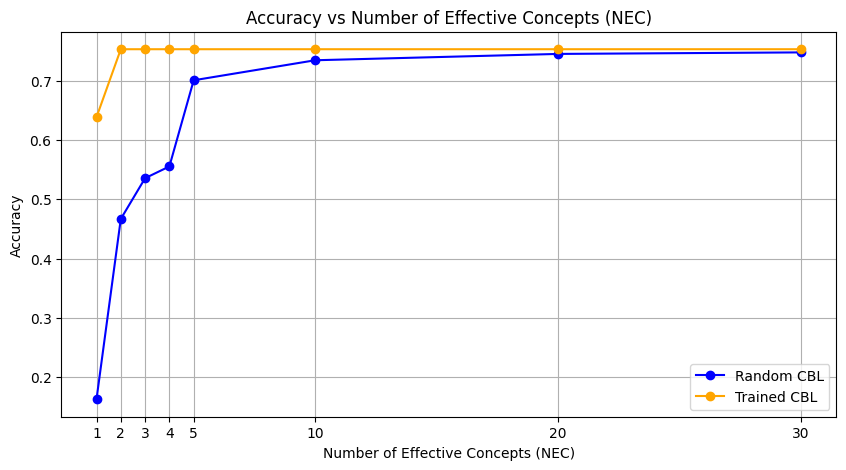

In [33]:
# Plot Graph of Accuracy vs Number of Effective Concepts: DO NOT CHANGE
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(NEC_LEVELS, RANDOM_CBL_ACCURACIES, marker='o', label='Random CBL', color='blue')
plt.plot(NEC_LEVELS, TRAINED_CBL_ACCURACIES, marker='o', label='Trained CBL', color='orange')
plt.title('Accuracy vs Number of Effective Concepts (NEC)')
plt.xlabel('Number of Effective Concepts (NEC)')
plt.ylabel('Accuracy')
plt.xticks(NEC_LEVELS)
plt.grid()
plt.legend()
# plt.savefig(os.path.join(HOME_DIR, "accuracy_vs_nec.png"))
plt.show()